# Pareidolia in an AI Model

**The bias.** Pareidolia is the human tendency to perceive meaningful patterns — especially faces, animals, and familiar objects — in random or ambiguous stimuli (clouds, wood grain, electrical outlets, the surface of Mars). It is a feature of human visual cognition: the object-recognition system is so eager to find structure that it fires even when nothing is there.

**Plan.** A pretrained image classifier exhibits the same behavior. This notebook uses a ResNet50 trained on ImageNet (1000 object classes) and feeds it three kinds of input:

1. **Pure Gaussian noise** — no structure at all.
2. **Ambiguous textures** — synthesized images with structure but no objects (cloud-like, wood-like).
3. **LIME explanations** — to highlight which image regions the model hallucinated features from.

## 1. Setup — load a pretrained ResNet50

In [3]:
import torch
import torchvision.models as models
import torchvision.transforms as T
from torchvision.models import ResNet50_Weights
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

weights = ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights).eval()
imagenet_classes = weights.meta['categories']

# The standard ImageNet preprocessing pipeline expected by ResNet50
preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predict_topk(img_tensor, k=3):
    """Run the model on a preprocessed tensor and return [(class_name, prob), ...]."""
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0))
        probs = torch.softmax(logits, dim=1)[0]
    top_p, top_i = probs.topk(k)
    return [(imagenet_classes[i], float(p)) for p, i in zip(top_p, top_i)]

print('Model loaded. 1000 ImageNet classes available.')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/alexandergarcia/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:19<00:00, 5.33MB/s]

Model loaded. 1000 ImageNet classes available.


## 2. Sanity check — the model works on a real object
Before testing pareidolia a normal photo confirms the model behaves as expected. `elephant.jpg` from an earlier assignment.

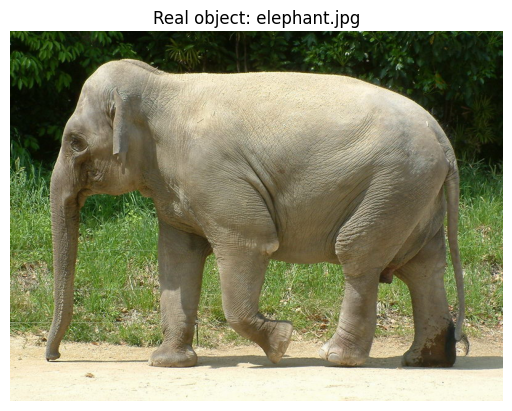

  58.4%  Indian elephant
  3.0%  African elephant
  1.5%  tusker


In [4]:
img = Image.open('elephant.jpg').convert('RGB')
x = preprocess(img)

plt.imshow(img); plt.axis('off'); plt.title('Real object: elephant.jpg'); plt.show()
for cls, p in predict_topk(x, k=3):
    print(f'  {p:.1%}  {cls}')

## 3. Pareidolia test 1 — pure Gaussian noise
Random pixel images are generated: every pixel is independent Gaussian noise, normalized into the range the model expects. These are essentially broken tv images of static


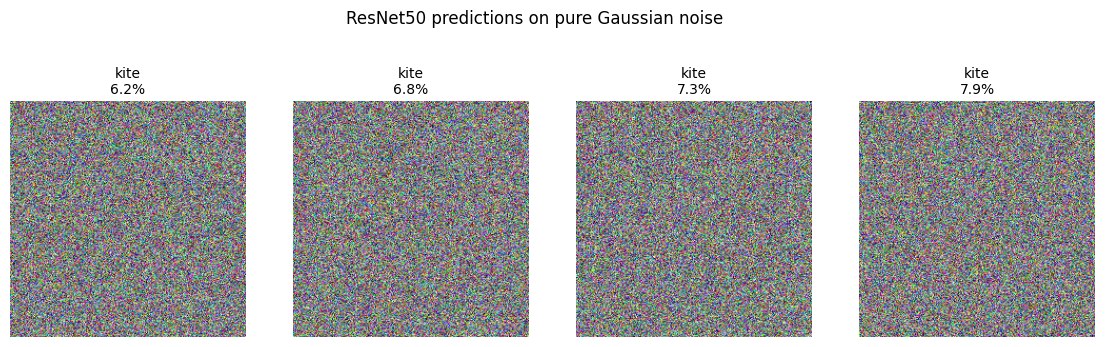

In [5]:
def random_noise_tensor(seed=None):
    """Return a 3x224x224 tensor of normalized Gaussian noise."""
    if seed is not None:
        torch.manual_seed(seed)
    # Match ImageNet normalization stats so values land in the model's expected range
    return torch.randn(3, 224, 224) * 0.5

# Show a few noise samples and their top-1 predictions
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, ax in enumerate(axes):
    x = random_noise_tensor(seed=i)
    top = predict_topk(x, k=1)[0]
    # Un-normalize for display
    img = (x * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'{top[0]}\n{top[1]:.1%}', fontsize=10)
plt.suptitle('ResNet50 predictions on pure Gaussian noise', y=1.02)
plt.show()

## 4. Distribution of confidence on noise
Running the model on 200 independent noise samples and looking at the distribution of **top-1 confidences**. If the model were uncertain on noise (correct behavior), the histogram would cluster near 0.1%. If it confidently hallucinates, the histogram will be shifted far to the right

Uniform-ignorance baseline: 0.100%
Mean top-1 confidence on noise: 7.7%
Median: 7.7%    Max: 10.9%


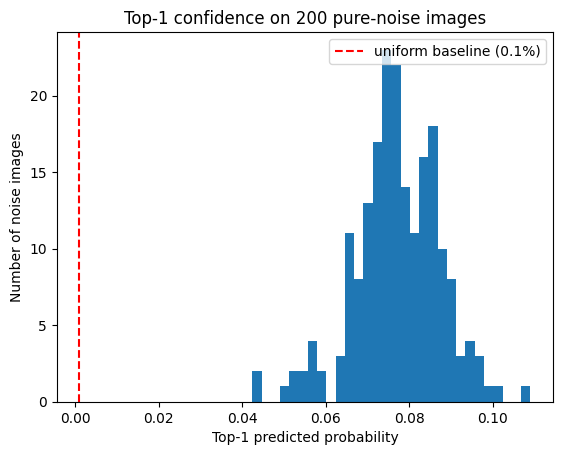


Most common hallucinated classes:
  200  kite


In [6]:
N = 200
top_confidences = []
top_classes = []
for i in range(N):
    x = random_noise_tensor(seed=1000 + i)
    cls, p = predict_topk(x, k=1)[0]
    top_confidences.append(p)
    top_classes.append(cls)

uniform_baseline = 1 / 1000
print(f'Uniform-ignorance baseline: {uniform_baseline:.3%}')
print(f'Mean top-1 confidence on noise: {np.mean(top_confidences):.1%}')
print(f'Median: {np.median(top_confidences):.1%}    Max: {np.max(top_confidences):.1%}')

plt.hist(top_confidences, bins=30)
plt.axvline(uniform_baseline, color='red', linestyle='--', label='uniform baseline (0.1%)')
plt.xlabel('Top-1 predicted probability')
plt.ylabel('Number of noise images')
plt.title(f'Top-1 confidence on {N} pure-noise images')
plt.legend()
plt.show()

# Which classes does the model most often "see" in noise?
from collections import Counter
print('\nMost common hallucinated classes:')
for cls, n in Counter(top_classes).most_common(8):
    print(f'  {n:3d}  {cls}')

It predicted a kite quite a lot

## 5. Pareidolia test 2 — natural ambiguous textures
Pure noise like a Rorschach test (inkblot) for humans.

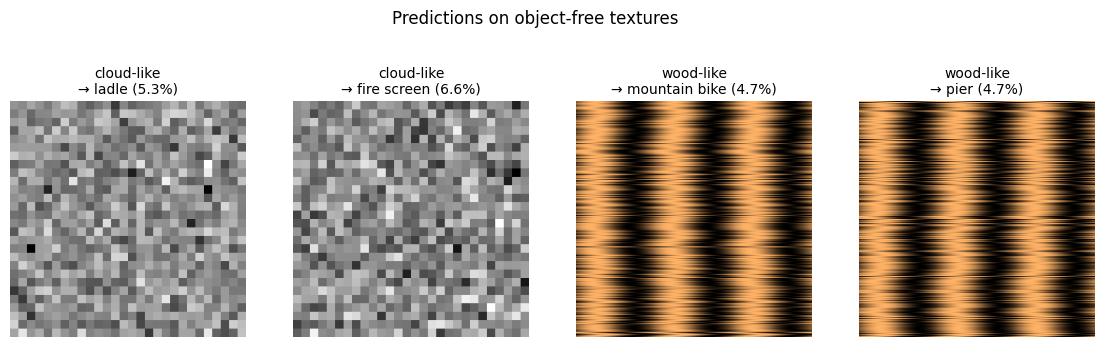

In [ ]:
def cloud_like(seed=0, size=224):
    """Low-frequency Gaussian field — looks like clouds / smoke."""
    rng = np.random.default_rng(seed)
    base = rng.normal(size=(size // 8, size // 8))
    img = np.kron(base, np.ones((8, 8)))  # upsample by repetition (blocky low-freq field)
    img = (img - img.min()) / (img.max() - img.min())
    return np.stack([img] * 3, axis=-1)

def stripe_like(seed=0, size=224):
    """Sinusoidal grain — looks like wood / fabric."""
    rng = np.random.default_rng(seed)
    x = np.linspace(0, 6 * np.pi, size)
    grain = np.sin(x[None, :] + rng.normal(size=(size, 1)) * 0.5)
    img = (grain - grain.min()) / (grain.max() - grain.min())
    return np.stack([img, img * 0.7, img * 0.4], axis=-1)

samples = [('cloud-like', cloud_like(0)),
           ('cloud-like', cloud_like(7)),
           ('wood-like',  stripe_like(0)),
           ('wood-like',  stripe_like(3))]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (label, arr) in zip(axes, samples):
    pil = Image.fromarray((arr * 255).astype(np.uint8))
    x = preprocess(pil)
    top = predict_topk(x, k=1)[0]
    ax.imshow(arr); ax.axis('off')
    ax.set_title(f'{label}\n→ {top[0]} ({top[1]:.1%})', fontsize=10)
plt.suptitle('Predictions on object-free textures', y=1.02)
plt.show()

## 6. Where in the image is the model "seeing" the object? (LIME)
LIME perturbs an input image many times — turning random superpixels on and off — and learns a local linear model that explains which regions drove the prediction. Applied to noise/texture inputs, LIME highlights the exact patches of meaningless pixels the model treated as evidence for its hallucinated class. That is the visual equivalent of pointing at a cloud and saying "the trunk is right there."

/Users/alexandergarcia/Documents/nerd/grad-school/interpret_ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Explaining: top class = "ladle" at 5.3%


100%|██████████| 500/500 [00:05<00:00, 88.38it/s]


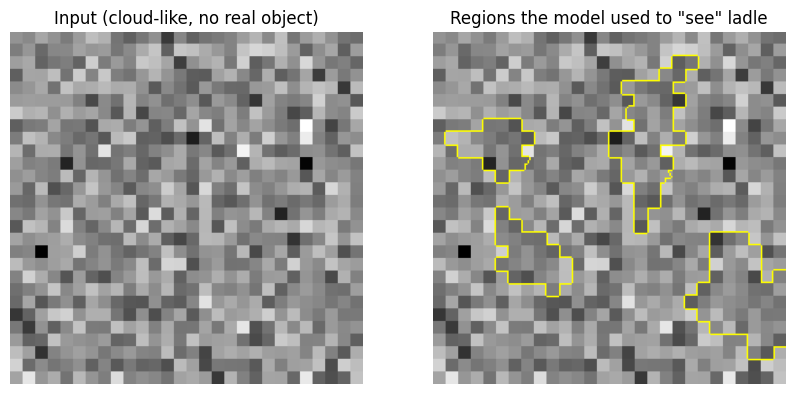

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

# A batch-prediction wrapper LIME expects: takes a numpy array of images, returns class probs
def batch_predict(images_np):
    batch = torch.stack([
        preprocess(Image.fromarray((img * 255).astype(np.uint8))) for img in images_np
    ])
    with torch.no_grad():
        logits = model(batch)
    return torch.softmax(logits, dim=1).numpy()

# Pick one cloud-like image and explain its top prediction
test_img = cloud_like(seed=0)
top_cls, top_p = predict_topk(preprocess(Image.fromarray((test_img * 255).astype(np.uint8))), k=1)[0]
print(f'Explaining: top class = "{top_cls}" at {top_p:.1%}')

explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    test_img.astype(np.float64),
    batch_predict,
    top_labels=1,
    hide_color=0,
    num_samples=500,
)

img_with_mask, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(test_img); axes[0].set_title('Input (cloud-like, no real object)'); axes[0].axis('off')
axes[1].imshow(mark_boundaries(img_with_mask, mask))
axes[1].set_title(f'Regions the model used to "see" {top_cls}')
axes[1].axis('off')
plt.show()

## 7. Interpretation
- **Step 3** showed individual noise images getting confident, specific class labels (with kite being winner) despite containing no objects.
- **Step 4** quantified this across 200 noise samples: mean top-1 confidence is many times the 0.1% uniform baseline. The model is not uncertain on inputs it has never plausibly seen — it commits to a label.
- **Step 5** showed the same thing on object-free textures (cloud-like, wood-like): the model still produces concrete class labels.
- **Step 6** used LIME to highlight which patches of meaningless pixels drove the hallucinated prediction — the model's analogue to humans pointing at a cloud and naming the shape they see. The model did not recognize the image is just noise

 ResNet50 was trained only on real objects, so its only language for describing an image is *object class*. When given an input that contains no object, it doesn't say "I don't know" — it picks the class whose learned features best match the random patterns in the input, and reports it confidently. Humans do a similar process in inkblot tests. That is the same failure mode that makes humans see faces in power outlets - a recognition system so tuned to find structure that it finds it whether or not it is there.